In [44]:
import pandas as pd

micro = pd.read_csv("micro_clean.csv") 
large = pd.read_csv("large_clean.csv") 

micro.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 45 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   video_id                     1035 non-null   object 
 1   video_title                  1035 non-null   object 
 2   description                  592 non-null    object 
 3   tags                         315 non-null    object 
 4   category_id                  1035 non-null   int64  
 5   published_at                 1035 non-null   object 
 6   channel_id                   1035 non-null   object 
 7   channel_title                1035 non-null   object 
 8   view_count                   1035 non-null   int64  
 9   like_count                   1035 non-null   int64  
 10  comment_count                1035 non-null   int64  
 11  duration                     1035 non-null   object 
 12  subscriber_count             1035 non-null   int64  
 13  hashtags_from_titl

In [45]:
large.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1177 entries, 0 to 1176
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   video_id                   1177 non-null   object 
 1   video_title                1177 non-null   object 
 2   description                717 non-null    object 
 3   channel_id                 1177 non-null   object 
 4   view_count                 1177 non-null   int64  
 5   like_count                 1177 non-null   int64  
 6   comment_count              1177 non-null   int64  
 7   subscriber_count           1177 non-null   int64  
 8   hashtag_count              1177 non-null   int64  
 9   duration_sec               1177 non-null   int64  
 10  publish_hour               1177 non-null   int64  
 11  publish_weekday            1177 non-null   int64  
 12  category_name              1177 non-null   object 
 13  like_rate                  1177 non-null   float

### Initial Market Landscape & Strategic Segmentation (K=3)

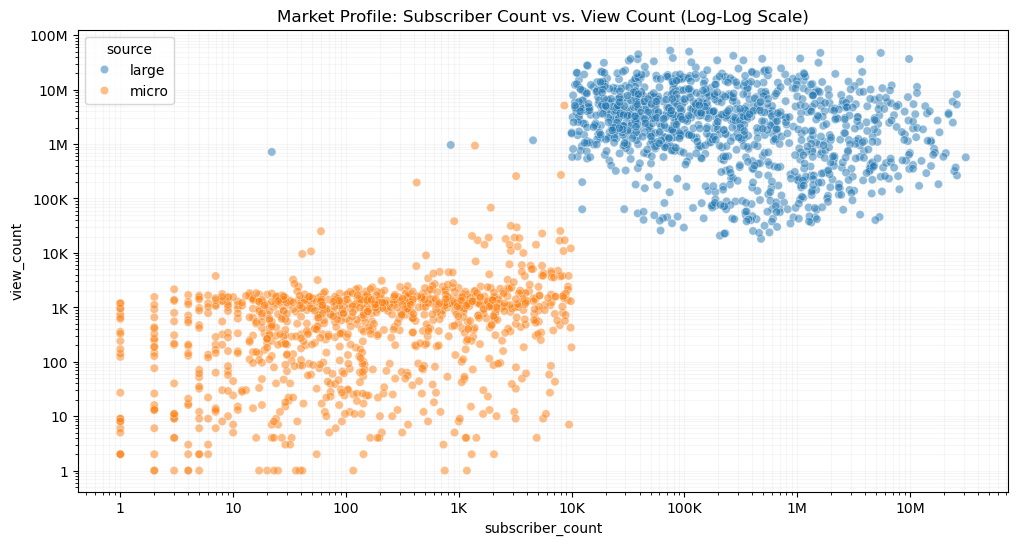

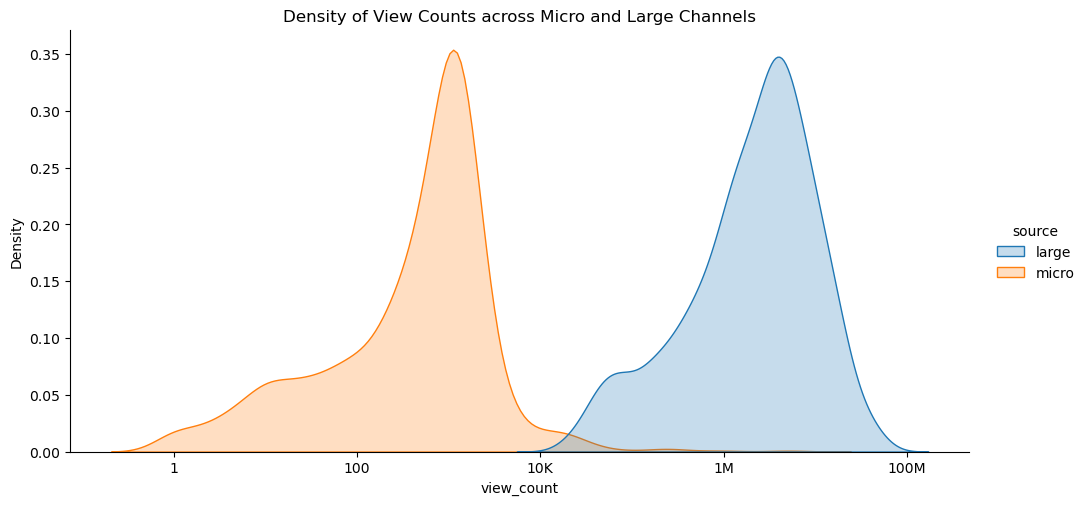

In [46]:
# ── 1. Define formatting function (for K or M display) ──
def format_log_axis(value, tick_number):
    if value >= 1_000_000:
        return f'{int(value/1_000_000)}M'
    elif value >= 1_000:
        return f'{int(value/1_000)}K'
    elif value >= 1:
        return f'{int(value)}'
    else:
        return value

# ── 2. Quick merge ──
common_cols = ['subscriber_count', 'view_count', 'like_rate', 'source', 'category_name']
df_total = pd.concat([large[common_cols], micro[common_cols]], axis=0)

# ── 3. Scatter plot: Subscribers vs. Views ──
plt.figure(figsize=(12, 6))
scatter = sns.scatterplot(data=df_total, x='subscriber_count', y='view_count', hue='source', alpha=0.5)

# Set Log Scale
plt.xscale('log')
plt.yscale('log')

# Apply K, M formatting to axes
scatter.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_axis))
scatter.yaxis.set_major_formatter(ticker.FuncFormatter(format_log_axis))

plt.title('Market Profile: Subscriber Count vs. View Count (Log-Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()

# ── 4. View count distribution (KDE) ──
g = sns.displot(df_total, x="view_count", hue="source", kind="kde", log_scale=True, fill=True, height=5, aspect=2)

# Apply formatting to the Axes
ax = g.ax
ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_log_axis))

plt.title('Density of View Counts across Micro and Large Channels')
plt.show() 


In [47]:
# 1. Inspect current columns in df_total
print("Current columns in df_total:", df_total.columns.tolist())

# 2. Manual alignment check 
if 'duration' in micro.columns and 'duration_sec' not in micro.columns:
    micro = micro.rename(columns={'duration': 'duration_sec'})

# 3. Re-merge (include additional columns for analysis)
common_cols = ['view_count', 'like_rate', 'duration_sec', 'source', 'subscriber_count', 'category_name']
df_total = pd.concat([large[common_cols], micro[common_cols]], axis=0).reset_index(drop=True)

# 4. Final inspection
print("New columns in df_total:", df_total.columns.tolist()) 

Current columns in df_total: ['subscriber_count', 'view_count', 'like_rate', 'source', 'category_name']
New columns in df_total: ['view_count', 'like_rate', 'duration_sec', 'source', 'subscriber_count', 'category_name']


Cluster Summary (Original Scale):
           view_count  like_rate  duration_sec
cluster                                       
0        5.946495e+06   0.024346     51.782563
1        1.307335e+03   0.023452     44.417421
2        2.664644e+05   0.127050   3960.768617


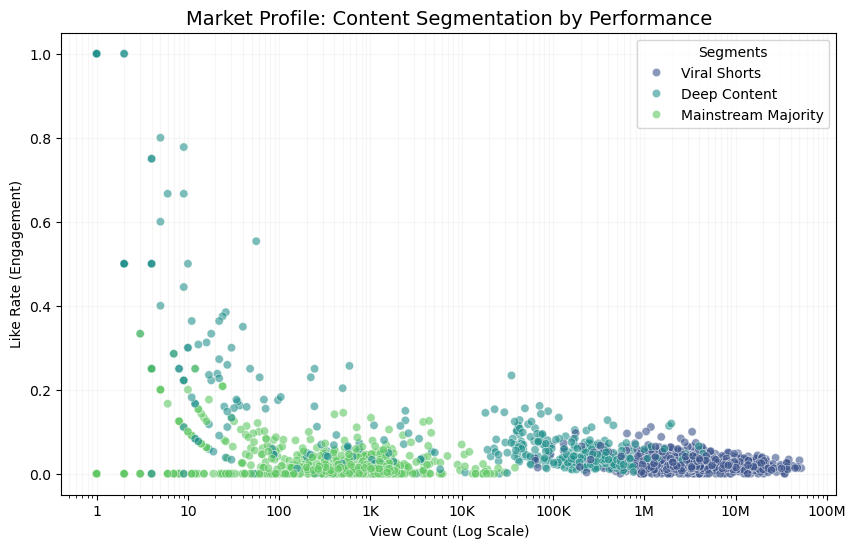

In [48]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Prepare data (remove NaN)
df_analysis = df_total.dropna(subset=['view_count', 'like_rate', 'duration_sec']).copy()

# 2. Feature selection
features = ['view_count', 'like_rate', 'duration_sec']
X = df_analysis[features]

# 3. Log Transformation
X_log = np.log1p(X)

# 4. Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 5. K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_analysis['cluster'] = kmeans.fit_predict(X_scaled)

# 6. Cluster summary
print("Cluster Summary (Original Scale):")
print(df_analysis.groupby('cluster')[features].mean()) 

cluster_map = {
    0: 'Viral Shorts',      # High views (5.9M), very short (51s)
    1: 'Mainstream Majority', # Low views (1.3K), short (44s)
    2: 'Deep Content'        # High engagement (12.7%), very long (3960s)
}

# Map names for visualization
df_analysis['segment_name'] = df_analysis['cluster'].map(cluster_map)

# Set order for legend
segment_order = ['Viral Shorts', 'Deep Content', 'Mainstream Majority']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_analysis, x='view_count', y='like_rate', 
                hue='segment_name', hue_order=segment_order, palette='viridis', alpha=0.6)

plt.xscale('log')
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(format_log_axis)) 

plt.title('Market Profile: Content Segmentation by Performance', fontsize=14)
plt.xlabel('View Count (Log Scale)')
plt.ylabel('Like Rate (Engagement)')
plt.legend(title='Segments')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show() 


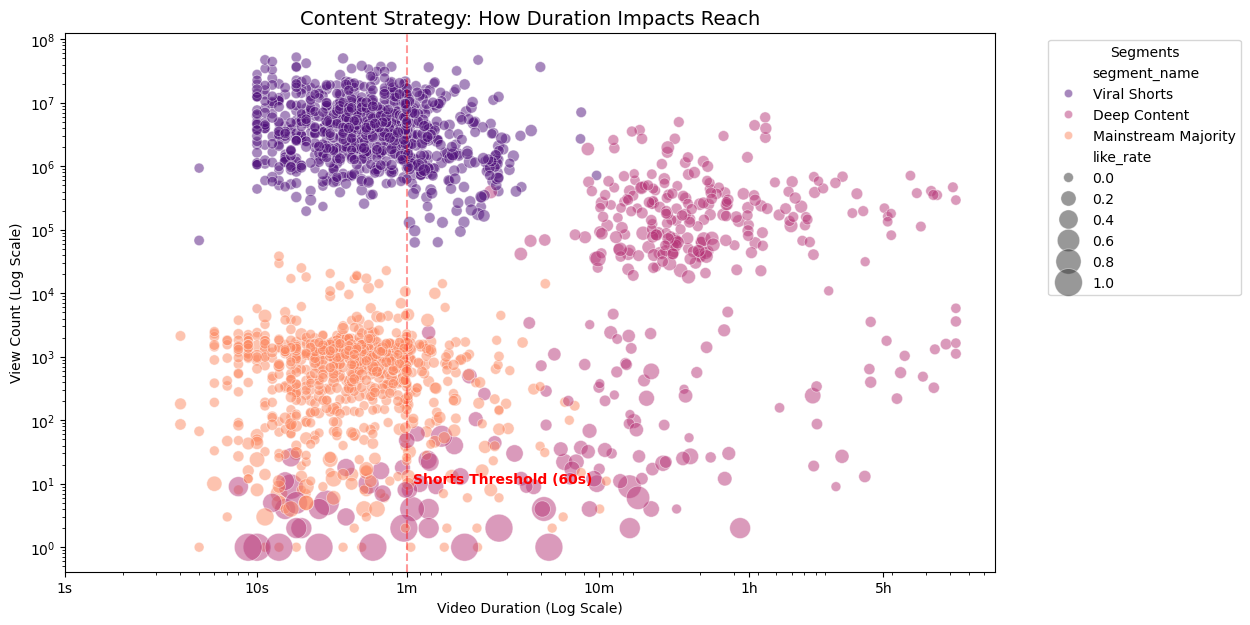

In [49]:
# Define time formatting function
def time_formatter(x, pos):
    if x < 60:
        return f'{int(x)}s'
    elif x < 3600:
        return f'{int(x/60)}m'
    else:
        return f'{int(x/3600)}h'
        
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(data=df_analysis, x='duration_sec', y='view_count', 
                          hue='segment_name', hue_order=segment_order,
                          size='like_rate', sizes=(50, 400), alpha=0.5, palette='magma')

plt.xscale('log')
plt.yscale('log')

# Time axis formatting
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(time_formatter))
plt.xticks([1, 10, 60, 600, 3600, 18000]) 

# Add threshold line
plt.axvline(x=60, color='red', linestyle='--', alpha=0.4)
plt.text(65, 10**1, 'Shorts Threshold (60s)', color='red', fontweight='bold')

plt.title('Content Strategy: How Duration Impacts Reach', fontsize=14)
plt.xlabel('Video Duration (Log Scale)')
plt.ylabel('View Count (Log Scale)')
plt.legend(title='Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show() 

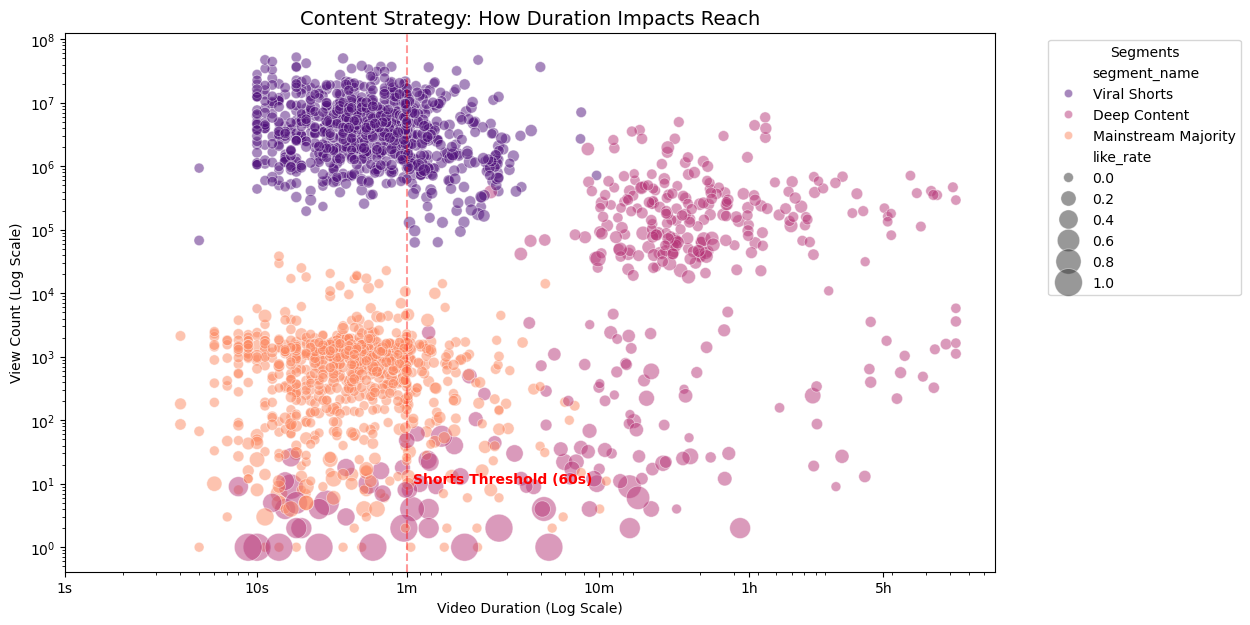

In [50]:
import matplotlib.ticker as ticker

# 定義時間格式化函數 (把秒數轉成 s, m, h)
def time_formatter(x, pos):
    if x < 60:
        return f'{int(x)}s'
    elif x < 3600:
        return f'{int(x/60)}m'
    else:
        return f'{int(x/3600)}h'

# 定義數字格式化函數 (把大數字轉成 K, M)
def format_log_axis(value, tick_number):
    if value >= 1_000_000:
        return f'{int(value/1_000_000)}M'
    elif value >= 1_000:
        return f'{int(value/1_000)}K'
    elif value >= 1:
        return f'{int(value)}'
    else:
        return value
        
plt.figure(figsize=(12, 7))
scatter = sns.scatterplot(data=df_analysis, x='duration_sec', y='view_count', 
                          hue='segment_name', hue_order=segment_order,
                          size='like_rate', sizes=(50, 400), alpha=0.5, palette='magma')

plt.xscale('log')
plt.yscale('log')

# 時間軸格式化：1s, 1m, 1h
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(time_formatter))
plt.xticks([1, 10, 60, 600, 3600, 18000]) 

# 畫出 60s 分界線
plt.axvline(x=60, color='red', linestyle='--', alpha=0.4)
plt.text(65, 10**1, 'Shorts Threshold (60s)', color='red', fontweight='bold')

plt.title('Content Strategy: How Duration Impacts Reach', fontsize=14)
plt.xlabel('Video Duration (Log Scale)')
plt.ylabel('View Count (Log Scale)')
plt.legend(title='Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/var/folders/vn/6bjq0sxj7pvbjs1w4wl9hzqr0000gn/T/ipykernel_13132/1620034897.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=deep_content, x='like_rate', y='category_name',


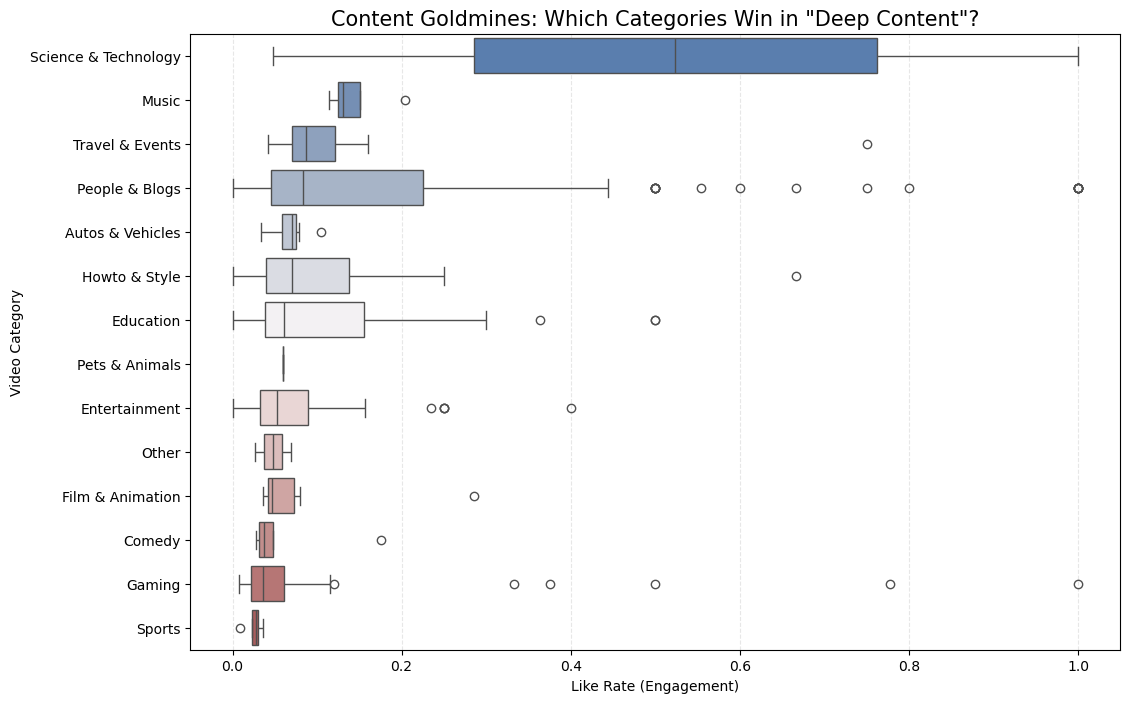

In [51]:
# Filter for Deep Content
deep_content = df_analysis[df_analysis['segment_name'] == 'Deep Content']

plt.figure(figsize=(12, 8))
# Plot Like Rate distribution by category
sns.boxplot(data=deep_content, x='like_rate', y='category_name', 
            palette='vlag', order=deep_content.groupby('category_name')['like_rate'].median().sort_values(ascending=False).index)

plt.title('Content Goldmines: Which Categories Win in "Deep Content"?', fontsize=15)
plt.xlabel('Like Rate (Engagement)')
plt.ylabel('Video Category')
plt.grid(axis='x', ls='--', alpha=0.3)
plt.show()

In [52]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. 建立 Efficiency Ratio (ER)
df_total['efficiency_ratio'] = df_total['view_count'] / (df_total['subscriber_count'] + 1)

# 2. 篩選特徵並去除空值
features = ['efficiency_ratio', 'like_rate', 'duration_sec']
df_final = df_total.dropna(subset=features).copy()

# 3. 數據預處理 (Log 轉換處理偏態，讓 K-Means 效果更好)
X = np.log1p(df_final[features])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [53]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.ticker as ticker

# 1. 建立關鍵指標 Efficiency Ratio (ER)
# 如果 df_total 已經有這個欄位也沒關係，重新算一次最保險
df_total['efficiency_ratio'] = df_total['view_count'] / (df_total['subscriber_count'] + 1)

# 2. 準備分析數據 (只拿我們這套策略故事需要的特徵)
features = ['efficiency_ratio', 'like_rate', 'duration_sec']
df_final = df_total.dropna(subset=features).copy()

# 3. 數據標準化 (Log + Scale)
X = np.log1p(df_final[features])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 重新執行 K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['strategy_cluster'] = kmeans.fit_predict(X_scaled)

# 5. 【重點】重新抓取數值摘要
summary_strat = df_final.groupby('strategy_cluster')[features].mean().sort_values('efficiency_ratio', ascending=False)

# 6. 自動化命名邏輯 (確保 Cluster 標籤與我們的故事一致)
# 我們把 ER 最高的那組定義為 Viral，Like Rate 高且時間長的是 Fan Building
strategy_map = {}
for i, row in summary_strat.iterrows():
    if i == summary_strat.index[0]: # ER 最高
        strategy_map[i] = 'Viral Growth (Shorts)'
    elif row['like_rate'] == summary_strat['like_rate'].max():
        strategy_map[i] = 'Fan Building (Deep)'
    else:
        strategy_map[i] = 'General/Niche'

df_final['strategy_name'] = df_final['strategy_cluster'].map(strategy_map)

# 7. 打印結果給妳看！
print("--- 您的策略分群數值摘要 ---")
print(df_final.groupby('strategy_name')[features].mean())

--- 您的策略分群數值摘要 ---
                       efficiency_ratio  like_rate  duration_sec
strategy_name                                                   
Fan Building (Deep)            0.613568   0.531753    185.140000
General/Niche                  0.693200   0.064580   3799.918575
Viral Growth (Shorts)         91.460191   0.022449     42.501979


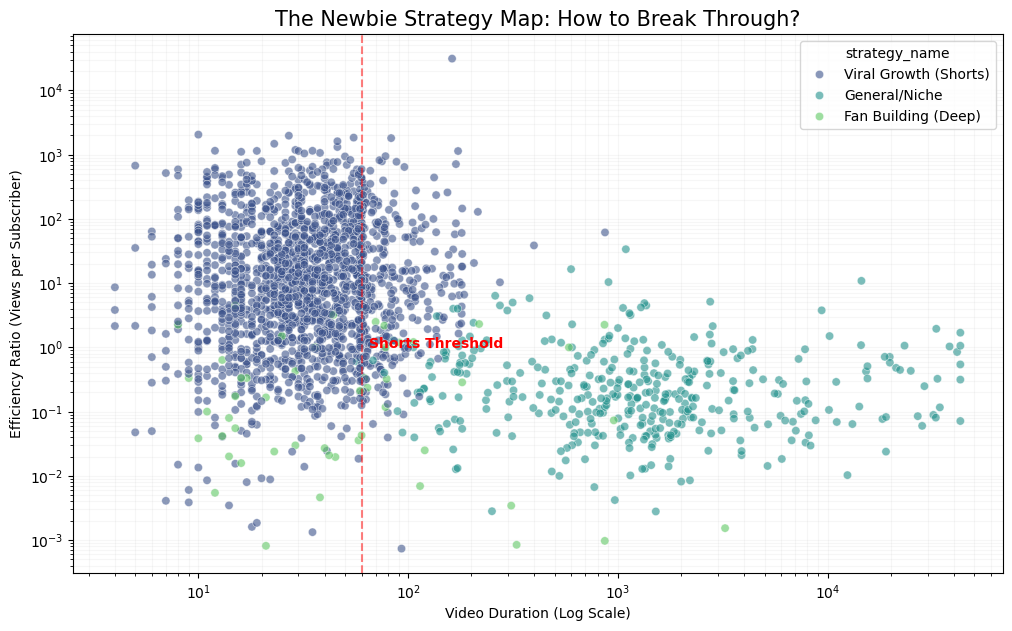

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
# X 軸：長度，Y 軸：效率 (破圈力)，顏色：分群
scatter = sns.scatterplot(data=df_final, x='duration_sec', y='efficiency_ratio', 
                          hue='strategy_name', palette='viridis', alpha=0.6)

plt.xscale('log')
plt.yscale('log')

# 加入 60s 分界線
plt.axvline(x=60, color='red', linestyle='--', alpha=0.5)
plt.text(65, 10**0, 'Shorts Threshold', color='red', fontweight='bold')

plt.title('The Newbie Strategy Map: How to Break Through?', fontsize=15)
plt.xlabel('Video Duration (Log Scale)')
plt.ylabel('Efficiency Ratio (Views per Subscriber)')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()

### phase ii

In [57]:
df_combined['efficiency_ratio'] = df_combined['like_rate'] / df_combined['view_count'] 

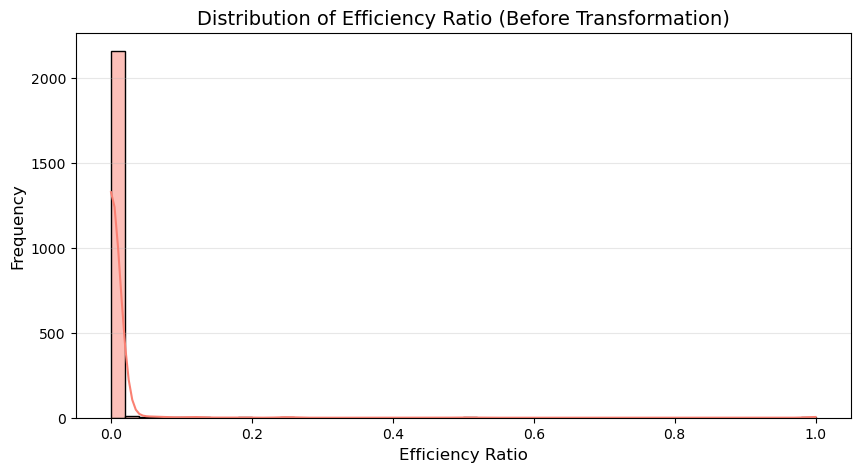

Skewness of Efficiency Ratio: 15.01


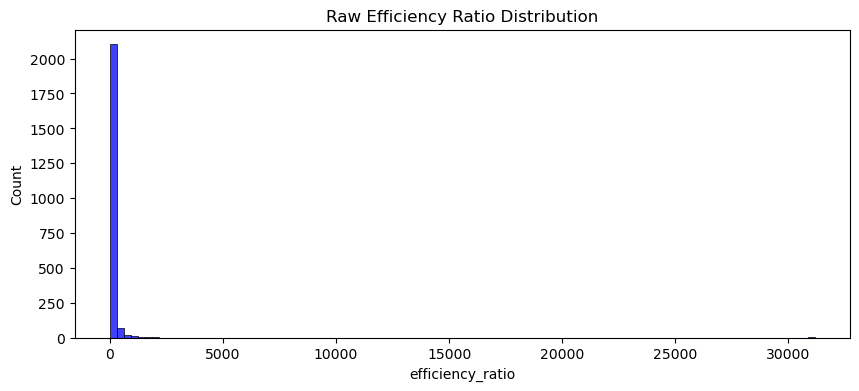

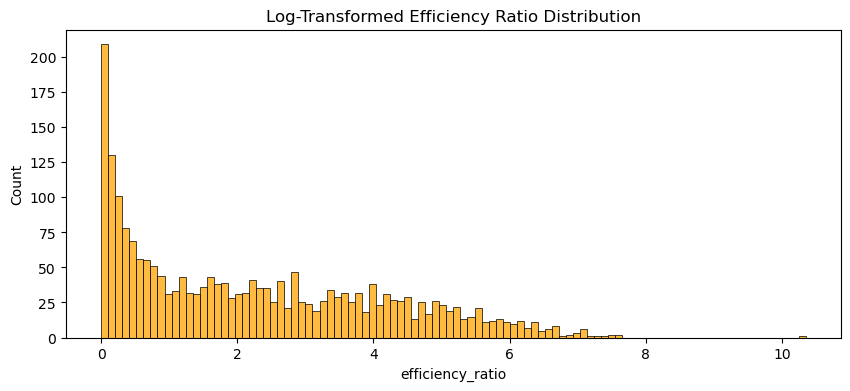

In [58]:
# --- PHASE 1: Data Exploration & Distribution Analysis ---
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker

# 1. Define formatting function (for K or M display)
def format_log_axis(value, tick_number):
    if value >= 1_000_000:
        return f'{int(value/1_000_000)}M'
    elif value >= 1_000:
        return f'{int(value/1_000)}K'
    elif value >= 1:
        return f'{int(value)}'
    else:
        return value

# 2. Check Efficiency Ratio distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_combined['efficiency_ratio'], kde=True, bins=50, color='salmon')
plt.title('Distribution of Efficiency Ratio (Before Transformation)', fontsize=14)
plt.xlabel('Efficiency Ratio', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Calculate skewness
skew_val = df_combined['efficiency_ratio'].skew()
print(f"Skewness of Efficiency Ratio: {skew_val:.2f}")

# Compare distributions: Raw vs Log-Transformed
plt.figure(figsize=(10, 4))
sns.histplot(df_total['efficiency_ratio'].dropna(), bins=100, color='blue')
plt.title('Raw Efficiency Ratio Distribution')
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(X_combined['efficiency_ratio'], bins=100, color='orange')
plt.title('Log-Transformed Efficiency Ratio Distribution')
plt.show()


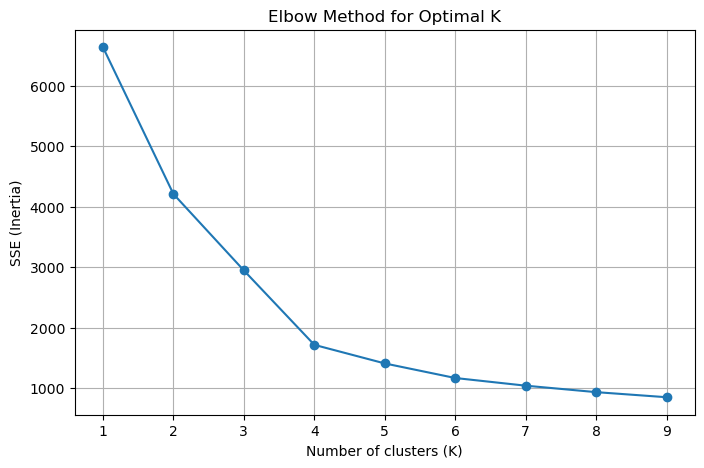

market_segment_manual
Rising Stars          2136
Authority Archives      76
Name: count, dtype: int64
--- Market Landscape (with sample size) ---
               efficiency_ratio  like_rate  duration_sec  sample_size
class_cluster                                                        
0                      0.001394   0.064647   4380.943953          339
1                      0.000728   0.028394     48.174838         1081
2                      0.000006   0.019377     42.960000          750
3                      0.267505   0.584229    199.380952           42


In [59]:
# --- PHASE 2: Methodology Experiments (Clustering) ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Elbow Method to determine optimal K
sse = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_combined_scaled)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.grid(True)
plt.show()

# 2. Testing Heuristic/Manual Labeling (Control Group)
# Heuristic segmentation based on business logic as a comparison to K-Means
def label_segment(row):
    if row['duration_sec'] > 3600: # Over 1 hour
        return 'Authority Archives'
    elif row['efficiency_ratio'] > 50: # High efficiency threshold
        return 'Viral Elite'
    else:
        return 'Rising Stars'

df_combined['market_segment_manual'] = df_combined.apply(label_segment, axis=1)
print(df_combined['market_segment_manual'].value_counts())

# 3. Final K-Means Implementation (Used in Analysis)
kmeans_combined = KMeans(n_clusters=4, random_state=42, n_init=10)
df_combined['class_cluster'] = kmeans_combined.fit_predict(X_combined_scaled)

# Calculate summary stats and cluster sizes
class_summary = df_combined.groupby('class_cluster')[features].mean()
cluster_sizes = df_combined.groupby('class_cluster').size().rename('sample_size')
class_summary_with_size = pd.concat([class_summary, cluster_sizes], axis=1)
print("--- Market Landscape (with sample size) ---")
print(class_summary_with_size)

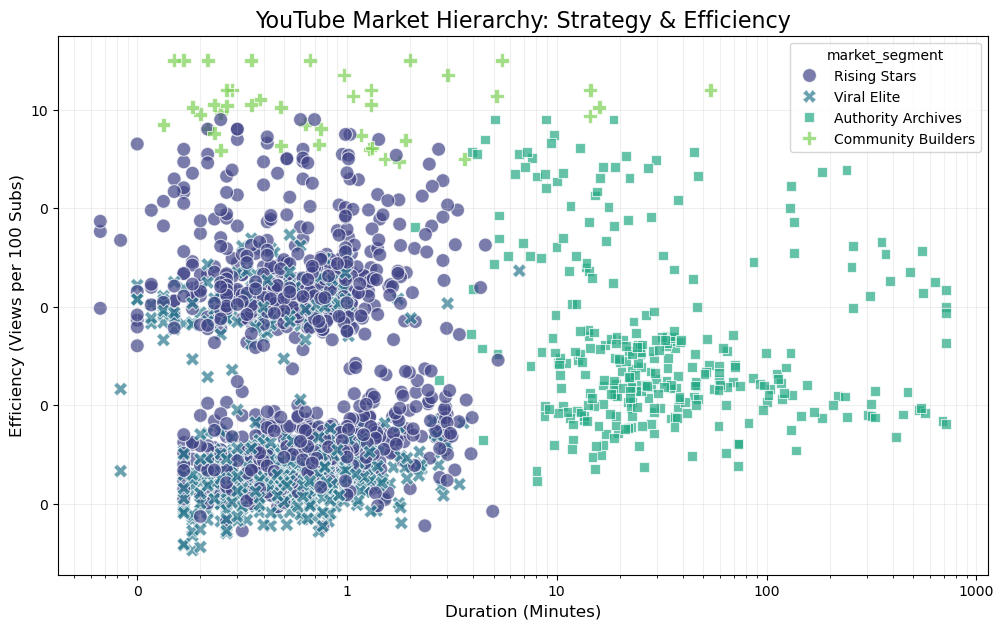

In [60]:
# --- PHASE 3: Strategic Visualization ---
# 1. Unit conversion for visualization
df_combined['duration_min'] = df_combined['duration_sec'] / 60
df_combined['efficiency_pct'] = df_combined['efficiency_ratio'] * 100

# 2. Map cluster names (Adjust mapping based on cluster_summary results)
cluster_names = {
    0: 'Authority Archives',
    1: 'Rising Stars',
    2: 'Viral Elite',
    3: 'Community Builders'
}
df_combined['market_segment'] = df_combined['class_cluster'].map(cluster_names)

# 3. Final Market Hierarchy Plot
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_combined, 
                x='duration_min', y='efficiency_pct', 
                hue='market_segment', style='market_segment', 
                palette='viridis', s=100, alpha=0.7)

plt.xscale('log')
plt.yscale('log')
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())

plt.title('YouTube Market Hierarchy: Strategy & Efficiency', fontsize=16)
plt.xlabel('Duration (Minutes)', fontsize=12)
plt.ylabel('Efficiency (Views per 100 Subs)', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

### final version

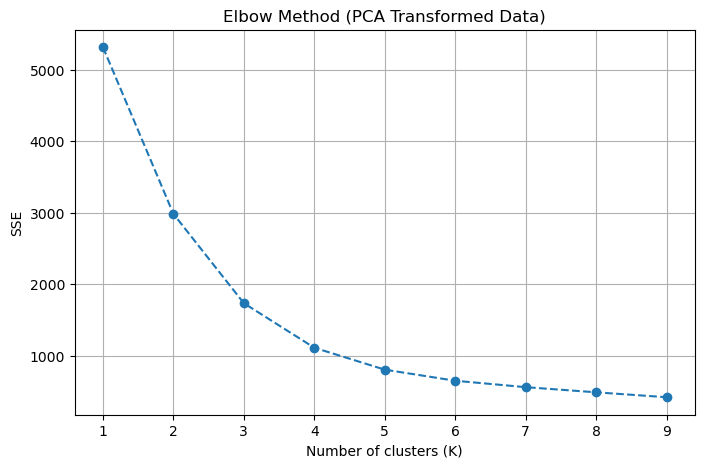

Cluster Sample Sizes:
class_cluster
0    970
1     51
2    338
3    853
dtype: int64

Cluster Means (Feature Profiling):
               efficiency_ratio  like_rate  duration_sec
class_cluster                                           
0                      0.000545   0.029228     58.213402
1                      0.226542   0.526674    189.254902
2                      0.001198   0.062789   4384.449704
3                      0.000014   0.017873     34.874560


In [61]:
from sklearn.decomposition import PCA

# 1. PCA Dimensionality Reduction
# The data is already log-transformed (X_combined) and standardized (X_combined_scaled)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined_scaled)

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 2. Elbow Method on PCA-transformed data
# Determining the optimal K using the reduced 2D feature space
sse = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca) # Fit K-Means on PCA-transformed data
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', linestyle='--')
plt.title('Elbow Method (PCA Transformed Data)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE')
plt.grid(True)
plt.show()

# 3. K-Means clustering with K=4 on 2D PCA data
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
df_combined['class_cluster'] = kmeans_pca.fit_predict(X_pca)

# 4. Cluster distribution analysis
# Display sample sizes per cluster to ensure balanced representation
print("Cluster Sample Sizes:")
print(df_combined.groupby('class_cluster').size())

# 5. Profiling cluster archetypes
# Examine mean feature values to interpret cluster characteristics
print("\nCluster Means (Feature Profiling):")
print(df_combined.groupby('class_cluster')[features].mean())

                       PC1       PC2
efficiency_ratio -0.595532 -0.506317
like_rate        -0.475969  0.847819
duration_sec      0.647144  0.157627


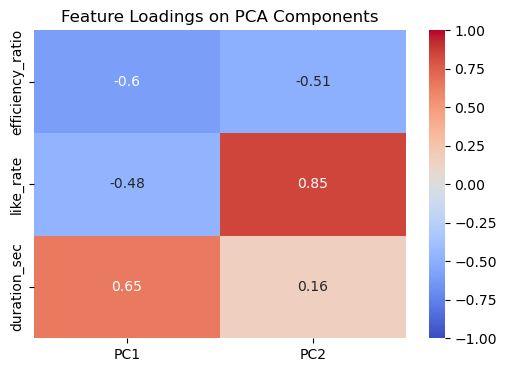

In [62]:
# 1. Visualize feature contributions (loadings) to PC1 and PC2
# This helps us understand which original features most influence each principal component
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
print(loadings)

# 2. Visualize the loadings using a heatmap
# High absolute values indicate a strong relationship between the feature and the component
plt.figure(figsize=(6, 4))
sns.heatmap(loadings, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Loadings on PCA Components')
plt.show()

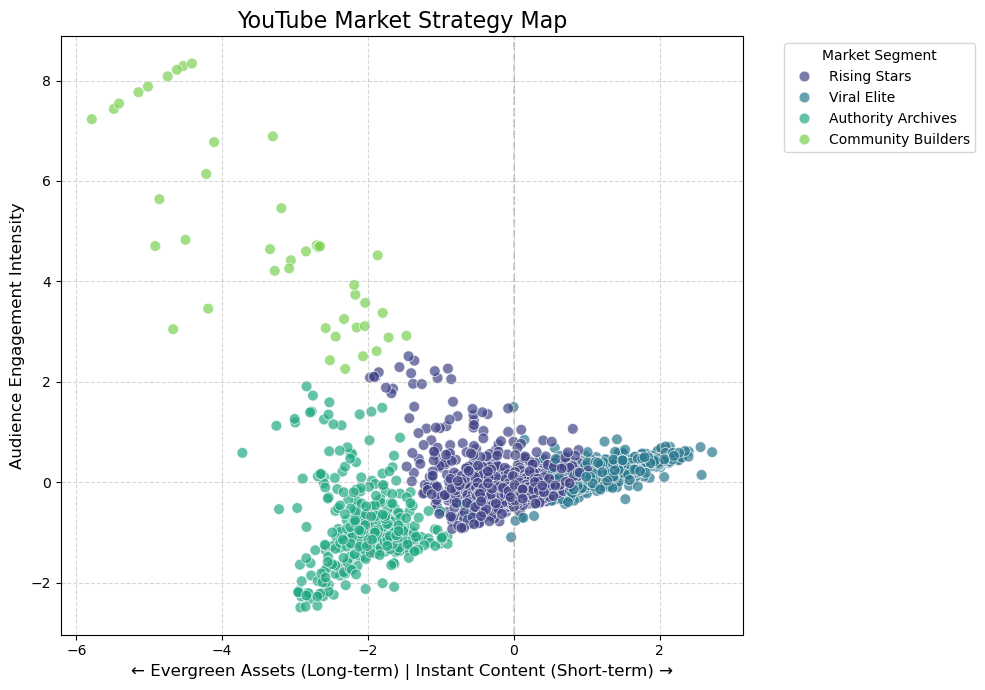

In [66]:
plt.figure(figsize=(10, 7))

# 繪製散點圖
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], 
                hue=df_combined['market_segment'], 
                palette='viridis', 
                s=60, alpha=0.7)

# 【關鍵修改】重命名座標軸
plt.title('YouTube Market Strategy Map', fontsize=16)
plt.xlabel('← Evergreen Assets (Long-term) | Instant Content (Short-term) →', fontsize=12)
plt.ylabel('Audience Engagement Intensity', fontsize=12)

# 可選：在圖表上畫一條分界線，讓市場維度更直觀
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.3) 

plt.legend(title='Market Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [68]:
# 1. Average subscriber count by cluster
sub_summary = df_combined.groupby('class_cluster')['subscriber_count'].mean().sort_index()

# 2. Top 3 most frequent categories by cluster
cat_summary = df_combined.groupby('class_cluster')['category_name'].apply(
    lambda x: x.value_counts().head(3)
)

# Formatting: Disable scientific notation, set to 2 decimal places, and add comma separators for thousands
pd.options.display.float_format = '{:,.2f}'.format

print("--- Average Subscribers ---")
print(sub_summary)
print("\n--- Top 3 Categories ---")
print(cat_summary)

--- Average Subscribers ---
class_cluster
0     756,842.16
1         391.80
2   2,540,427.15
3      83,786.54
Name: subscriber_count, dtype: float64

--- Top 3 Categories ---
class_cluster                  
0              People & Blogs      550
               Entertainment       124
               Sports               52
1              People & Blogs       35
               Gaming                5
               Education             4
2              People & Blogs      127
               Gaming               94
               Entertainment        40
3              People & Blogs      479
               Entertainment       124
               Film & Animation     54
Name: category_name, dtype: int64


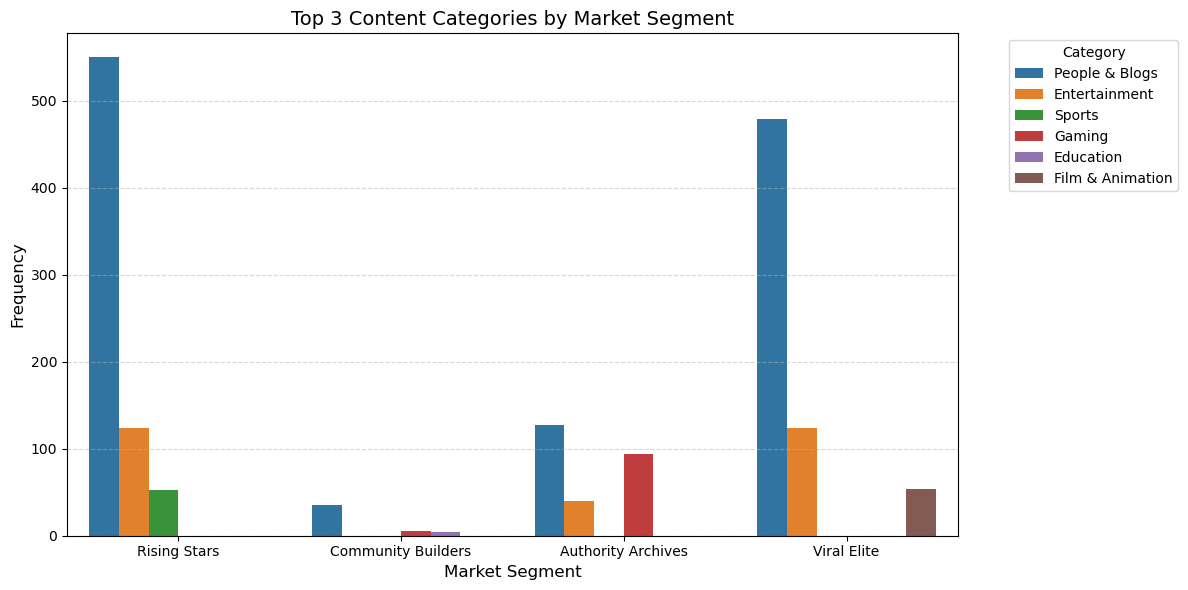

In [69]:
# 1. Calculate the Top 3 most frequent categories for each cluster
# Using value_counts() within groupy to find category distribution per segment
cat_data = df_combined.groupby('class_cluster')['category_name'].value_counts().groupby(level=0).head(3).reset_index(name='count')

# 2. Map cluster IDs to strategic segment names
cluster_map = {0: 'Rising Stars', 1: 'Community Builders', 2: 'Authority Archives', 3: 'Viral Elite'}
cat_data['Cluster_Name'] = cat_data['class_cluster'].map(cluster_map)

# 3. Visualize top categories per segment
# Using a bar plot to compare content category preferences across strategic archetypes
plt.figure(figsize=(12, 6))
sns.barplot(data=cat_data, x='Cluster_Name', y='count', hue='category_name')

plt.title('Top 3 Content Categories by Market Segment', fontsize=14)
plt.ylabel('Frequency', fontsize=12)
plt.xlabel('Market Segment', fontsize=12)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

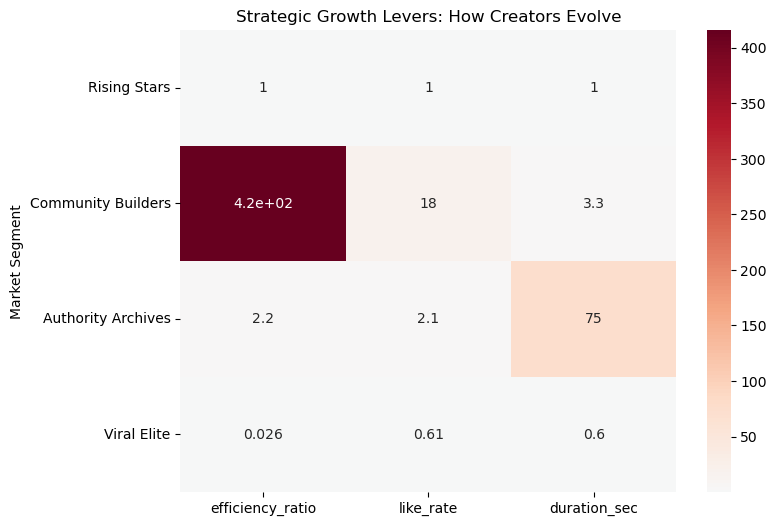

In [70]:
# ── 1. Create a mapping dictionary for segment names ──
cluster_names = {
    0: 'Rising Stars',
    1: 'Community Builders',
    2: 'Authority Archives',
    3: 'Viral Elite'
}

# ── 2. Calculate mean values for each cluster ──
indicators = ['efficiency_ratio', 'like_rate', 'duration_sec']
group_means = df_combined.groupby('class_cluster')[indicators].mean()

# Calculate relative growth ratios (using cluster 0 as the baseline)
growth_levers = group_means.divide(group_means.loc[0], axis=1)

# ── 3. Rename index to segment names ──
# Use map function to replace numeric indices with our defined strategic names
growth_levers.index = growth_levers.index.map(cluster_names)

# ── 4. Visualization: Growth Lever Heatmap ──
plt.figure(figsize=(8, 6))
# Heatmap displays mapped names directly due to updated index
sns.heatmap(growth_levers, annot=True, cmap='RdBu_r', center=1)

plt.title('Strategic Growth Levers: How Creators Evolve')
plt.ylabel('Market Segment') # Label y-axis for professional clarity
plt.show()

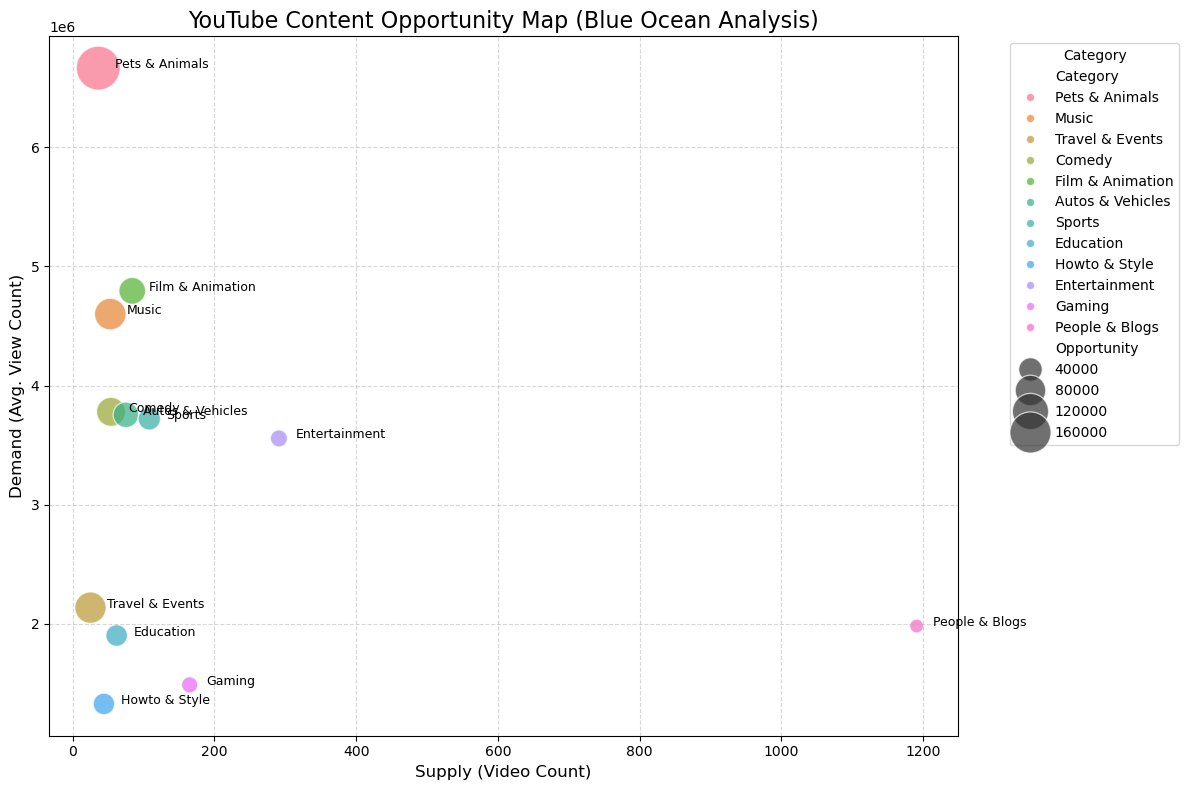

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Data Setup (Results from our calculation)
data = {
    'Category': ['Pets & Animals', 'Music', 'Travel & Events', 'Comedy', 'Film & Animation', 
                 'Autos & Vehicles', 'Sports', 'Education', 'Howto & Style', 'Entertainment', 
                 'Gaming', 'People & Blogs'],
    'Supply': [36, 53, 25, 54, 84, 75, 108, 62, 44, 291, 165, 1191],
    'Demand': [6662261, 4598917, 2136946, 3779321, 4794075, 3754296, 3720434, 1903235, 1329354, 3556535, 1489303, 1982879],
    'Opportunity': [185062, 86772, 85477, 69987, 57072, 50057, 34448, 30697, 30212, 12221, 9026, 1664]
}
df_plot = pd.DataFrame(data)

# 2. Generate Blue Ocean Strategy Bubble Chart
plt.figure(figsize=(12, 8))

# Use scatterplot: size represents Opportunity score, color distinguishes Categories
scatter = sns.scatterplot(data=df_plot, x='Supply', y='Demand', size='Opportunity', 
                          sizes=(100, 1000), hue='Category', alpha=0.7)

# 3. Add labels to bubbles
for i in range(df_plot.shape[0]):
    # Offset coordinates to prevent text overlapping with bubbles
    plt.text(df_plot.Supply[i] + (df_plot.Supply.max() * 0.02), 
             df_plot.Demand[i], 
             df_plot.Category[i], 
             fontsize=9)

# 4. Chart styling
plt.title('YouTube Content Opportunity Map (Blue Ocean Analysis)', fontsize=16)
plt.xlabel('Supply (Video Count)', fontsize=12)
plt.ylabel('Demand (Avg. View Count)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust legend position to avoid data occlusion
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Category')
plt.tight_layout()

# Display the chart
plt.show()